In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def parse_history_file(filename):
    headers = []
    data = []
    
    with open(filename, 'r') as f:
        for line in f:
            if not line.strip():
                continue
                
            # 处理注释行中的列名
            if line.startswith('# ['):
                # 先用']'分割行,这样可以分开每个列定义
                parts = line.strip('# \n').split(']')
                for part in parts:
                    if '=' in part:
                        # 提取等号后面的名称
                        header = part.split('=')[1].strip()
                        # 移除开头的'['(如果存在)
                        if header.startswith('['):
                            header = header[1:]
                        # 移除方括号及其中的数字
                        header = header.split('[')[0].strip()
                        if header:  # 确保不是空字符串
                            headers.append(header)
            
            # 处理数据行
            elif not line.startswith('#'):
                row_data = [float(x) for x in line.split()]
                data.append(row_data)
    
    # 将数据转换为字典格式
    result = {}
    for i, header in enumerate(headers):
        result[header] = [row[i] for row in data]
    
    return result

In [3]:
file_path0 = "/home/zhangzelin/projects/kharma/output/20241216_hip_sane_a05000_576-512-1_smr-2_6-12_rout1000_min020_gamma13/torus.hst"
file_path1 = "/home/zhangzelin/projects/kharma/output/20241216_hip_sane_a09375_576-512-1_smr-2_6-12_rout1000_min020_gamma13/torus.hst"
file_path2 = "/home/zhangzelin/projects/kharma/output/20241216_hip_kz_sane_a05000_eta-05_576-512-1_smr-2_6-12_rout1000_min020_gamma13/kz_torus.hst"
file_path3 = "/home/zhangzelin/projects/kharma/output/20241216_hip_kz_sane_a05000_eta+05_576-512-1_smr-2_6-12_rout1000_min020_gamma13/kz_torus.hst"
file_path4 = "/home/zhangzelin/projects/kharma/output/20241216_hip_kz_sane_a09375_eta-01_576-512-1_smr-2_6-12_rout1000_min020_gamma13/kz_torus.hst"
file_path5 = "/home/zhangzelin/projects/kharma/output/20241216_hip_kz_sane_a09375_eta+05_576-512-1_smr-2_6-12_rout1000_min020_gamma13/kz_torus.hst"

history_data0 = parse_history_file(file_path0)
history_data1 = parse_history_file(file_path1)
history_data2 = parse_history_file(file_path2)
history_data3 = parse_history_file(file_path3)
history_data4 = parse_history_file(file_path4)
history_data5 = parse_history_file(file_path5)

In [4]:
t0 = history_data0['time']
Phi_EH0 = history_data0['Phi_EH']
Phi_5M0 = history_data0['Phi_5M']
Mass0 = history_data0['Mass']
Mdot0 = history_data0['Mdot']
Mdot_EH0 = history_data0['Mdot_EH']
Mdot_5M0 = history_data0['Mdot_5M']
Mdot_Flux0 = history_data0['Mdot_Flux']

t1 = history_data1['time']
Phi_EH1 = history_data1['Phi_EH']
Phi_5M1 = history_data1['Phi_5M']
Mass1 = history_data1['Mass']
Mdot1 = history_data1['Mdot']
Mdot_EH1 = history_data1['Mdot_EH']
Mdot_5M1 = history_data1['Mdot_5M']
Mdot_Flux1 = history_data1['Mdot_Flux']

t2 = history_data2['time']
Phi_EH2 = history_data2['Phi_EH']
Phi_5M2 = history_data2['Phi_5M']
Mass2 = history_data2['Mass']
Mdot2 = history_data2['Mdot']
Mdot_EH2 = history_data2['Mdot_EH']
Mdot_5M2 = history_data2['Mdot_5M']
Mdot_Flux2 = history_data2['Mdot_Flux']

t3 = history_data3['time']
Phi_EH3 = history_data3['Phi_EH']
Phi_5M3 = history_data3['Phi_5M']
Mass3 = history_data3['Mass']
Mdot3 = history_data3['Mdot']
Mdot_EH3 = history_data3['Mdot_EH']
Mdot_5M3 = history_data3['Mdot_5M']
Mdot_Flux3 = history_data3['Mdot_Flux']

t4 = history_data4['time']
Phi_EH4 = history_data4['Phi_EH']
Phi_5M4 = history_data4['Phi_5M']
Mass4 = history_data4['Mass']
Mdot4 = history_data4['Mdot']
Mdot_EH4 = history_data4['Mdot_EH']
Mdot_5M4 = history_data4['Mdot_5M']
Mdot_Flux4 = history_data4['Mdot_Flux']

t5 = history_data5['time']
Phi_EH5 = history_data5['Phi_EH']
Phi_5M5 = history_data5['Phi_5M']
Mass5 = history_data5['Mass']
Mdot5 = history_data5['Mdot']
Mdot_EH5 = history_data5['Mdot_EH']
Mdot_5M5 = history_data5['Mdot_5M']
Mdot_Flux5 = history_data5['Mdot_Flux']

In [5]:
label0 = r'$kerr, a=0.5000$'
label1 = r'$kerr, a=0.9375$'
label2 = r'$kz, a=0.5000, \eta=-0.5$'
label3 = r'$kz, a=0.5000, \eta=+0.5$'
label4 = r'$kz, a=0.9375, \eta=-0.1$'
label5 = r'$kz, a=0.9375, \eta=+0.5$'



In [6]:
dp = 1
avt = 50

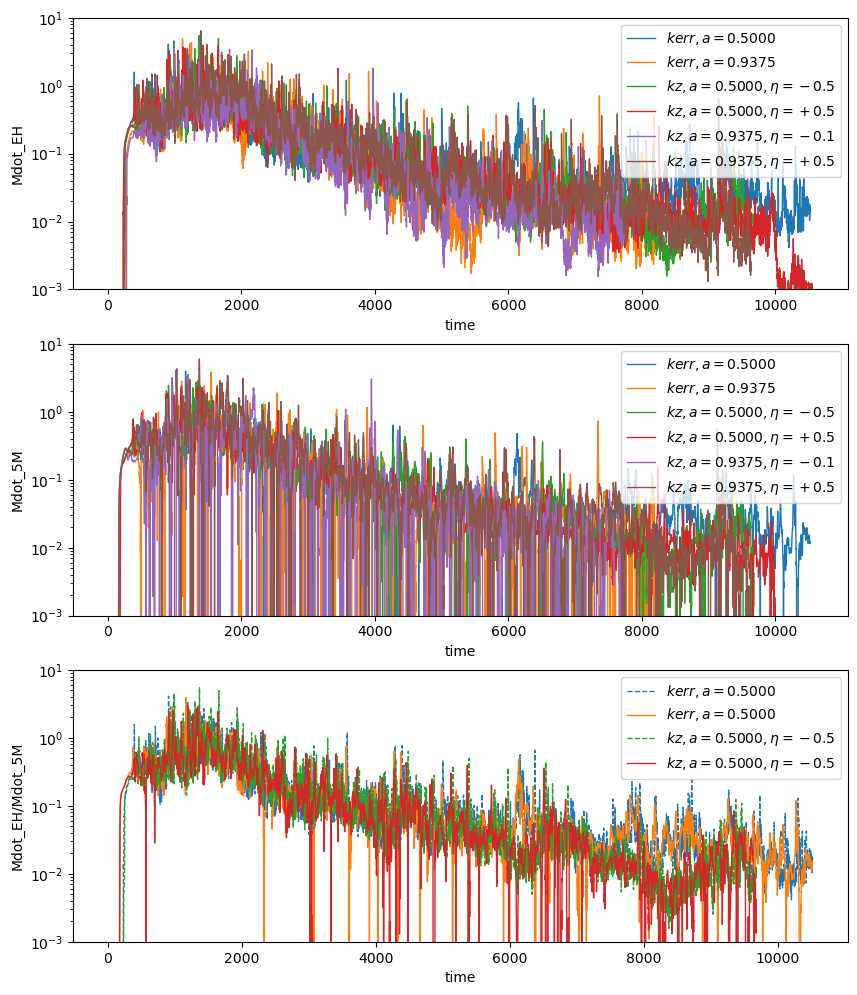

In [7]:
fig0, ax0 = plt.subplots(3,1,figsize=(10, 12))

ax0[0].plot(t0[::dp], Mdot_EH0[::dp], label=label0, alpha=1.0, linewidth=1.0)
ax0[0].plot(t1[::dp], Mdot_EH1[::dp], label=label1, alpha=1.0, linewidth=1.0)
ax0[0].plot(t2[::dp], Mdot_EH2[::dp], label=label2, alpha=1.0, linewidth=1.0)
ax0[0].plot(t3[::dp], Mdot_EH3[::dp], label=label3, alpha=1.0, linewidth=1.0)
ax0[0].plot(t4[::dp], Mdot_EH4[::dp], label=label4, alpha=1.0, linewidth=1.0)
ax0[0].plot(t5[::dp], Mdot_EH5[::dp], label=label5, alpha=1.0, linewidth=1.0)

ax0[0].set_xlabel('time')
ax0[0].set_ylabel('Mdot_EH')
ax0[0].legend()

ax0[1].plot(t0[::dp], Mdot_5M0[::dp], label=label0, alpha=1.0, linewidth=1.0)
ax0[1].plot(t1[::dp], Mdot_5M1[::dp], label=label1, alpha=1.0, linewidth=1.0)
ax0[1].plot(t2[::dp], Mdot_5M2[::dp], label=label2, alpha=1.0, linewidth=1.0)
ax0[1].plot(t3[::dp], Mdot_5M3[::dp], label=label3, alpha=1.0, linewidth=1.0)
ax0[1].plot(t4[::dp], Mdot_5M4[::dp], label=label4, alpha=1.0, linewidth=1.0)
ax0[1].plot(t5[::dp], Mdot_5M5[::dp], label=label5, alpha=1.0, linewidth=1.0)

ax0[1].set_xlabel('time')
ax0[1].set_ylabel('Mdot_5M')
ax0[1].legend()

ax0[2].plot(t0[::dp], Mdot_EH0[::dp], label=label0, alpha=1.0, linewidth=1.0, linestyle='--')
ax0[2].plot(t0[::dp], Mdot_5M0[::dp], label=label0, alpha=1.0, linewidth=1.0, linestyle='-')
ax0[2].plot(t2[::dp], Mdot_EH2[::dp], label=label2, alpha=1.0, linewidth=1.0, linestyle='--')
ax0[2].plot(t2[::dp], Mdot_5M2[::dp], label=label2, alpha=1.0, linewidth=1.0, linestyle='-')

ax0[2].set_xlabel('time')
ax0[2].set_ylabel('Mdot_EH/Mdot_5M')
ax0[2].legend()

ax0[0].set_yscale('log')
ax0[0].set_ylim(1e-3,1e1)
ax0[1].set_yscale('log')
ax0[1].set_ylim(1e-3,1e1)
ax0[2].set_yscale('log')
ax0[2].set_ylim(1e-3,1e1)

plt.show()

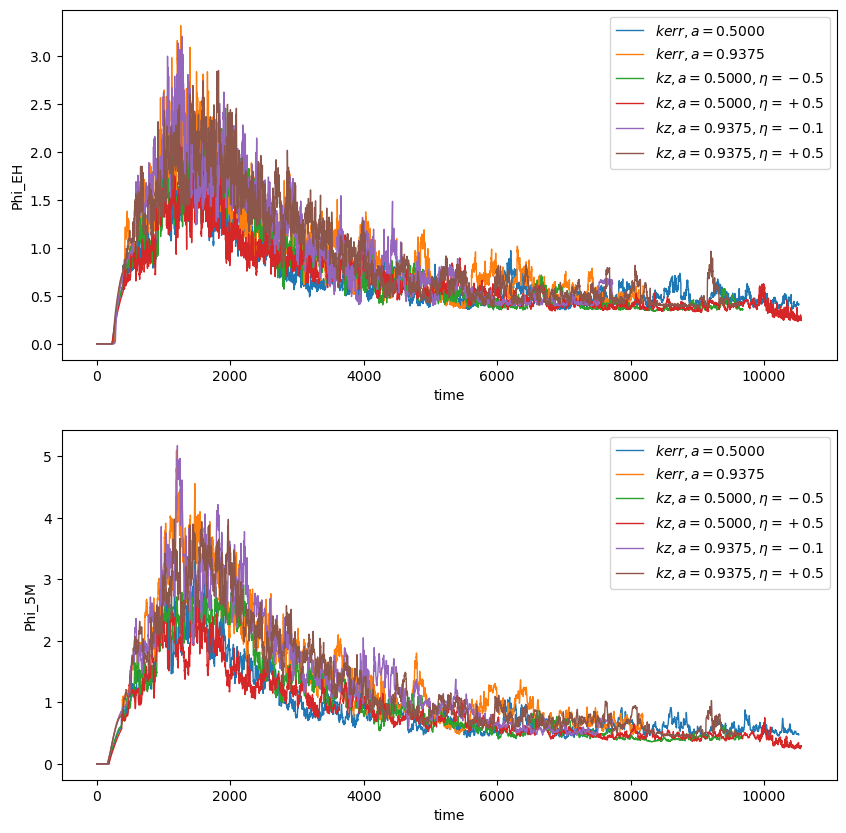

In [8]:
fig1, ax1 = plt.subplots(2,1,figsize=(10, 10))

ax1[0].plot(t0, Phi_EH0, label=label0, alpha=1.0, linewidth=1.0)
ax1[0].plot(t1, Phi_EH1, label=label1, alpha=1.0, linewidth=1.0)
ax1[0].plot(t2, Phi_EH2, label=label2, alpha=1.0, linewidth=1.0)
ax1[0].plot(t3, Phi_EH3, label=label3, alpha=1.0, linewidth=1.0)
ax1[0].plot(t4, Phi_EH4, label=label4, alpha=1.0, linewidth=1.0)
ax1[0].plot(t5, Phi_EH5, label=label5, alpha=1.0, linewidth=1.0)

ax1[0].legend()

ax1[1].plot(t0, Phi_5M0, label=label0, alpha=1.0, linewidth=1.0)
ax1[1].plot(t1, Phi_5M1, label=label1, alpha=1.0, linewidth=1.0)
ax1[1].plot(t2, Phi_5M2, label=label2, alpha=1.0, linewidth=1.0)
ax1[1].plot(t3, Phi_5M3, label=label3, alpha=1.0, linewidth=1.0)
ax1[1].plot(t4, Phi_5M4, label=label4, alpha=1.0, linewidth=1.0)
ax1[1].plot(t5, Phi_5M5, label=label5, alpha=1.0, linewidth=1.0)

ax1[1].legend()

# ax1[0].set_yscale('log')
# ax1[0].set_ylim(1e-1,1e1)
# ax1[1].set_yscale('log')
# ax1[1].set_ylim(1e-1,1e1)
ax1[0].set_xlabel('time')
ax1[0].set_ylabel('Phi_EH')
ax1[1].set_xlabel('time')
ax1[1].set_ylabel('Phi_5M')
plt.show()


/tmp/ipykernel_2458080/881804033.py:14: RuntimeWarning: invalid value encountered in sqrt
  ax2[1].plot(t0[::dp], Phi_5M0[::dp]/np.sqrt(Mdot_5M0[::dp]), label=label0, alpha=1.0, linewidth=1.0)
/tmp/ipykernel_2458080/881804033.py:15: RuntimeWarning: invalid value encountered in sqrt
  ax2[1].plot(t1[::dp], Phi_5M1[::dp]/np.sqrt(Mdot_5M1[::dp]), label=label1, alpha=1.0, linewidth=1.0)
/tmp/ipykernel_2458080/881804033.py:16: RuntimeWarning: invalid value encountered in sqrt
  ax2[1].plot(t2[::dp], Phi_5M2[::dp]/np.sqrt(Mdot_5M2[::dp]), label=label2, alpha=1.0, linewidth=1.0)
/tmp/ipykernel_2458080/881804033.py:17: RuntimeWarning: invalid value encountered in sqrt
  ax2[1].plot(t3[::dp], Phi_5M3[::dp]/np.sqrt(Mdot_5M3[::dp]), label=label3, alpha=1.0, linewidth=1.0)
/tmp/ipykernel_2458080/881804033.py:18: RuntimeWarning: invalid value encountered in sqrt
  ax2[1].plot(t4[::dp], Phi_5M4[::dp]/np.sqrt(Mdot_5M4[::dp]), label=label4, alpha=1.0, linewidth=1.0)
/tmp/ipykernel_2458080/881804033.py

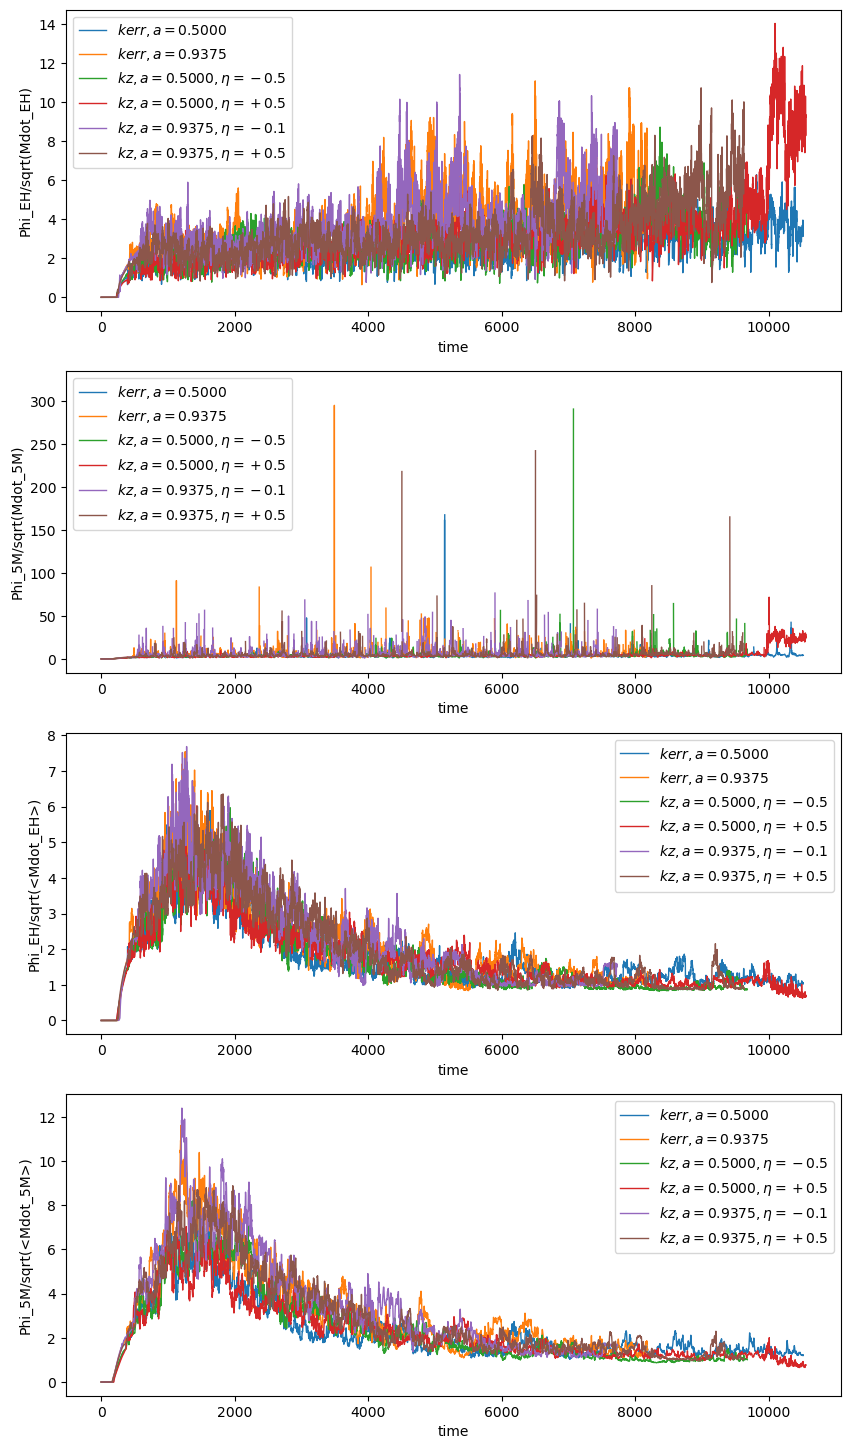

In [9]:
fig2, ax2 = plt.subplots(4,1,figsize=(10, 18))

ax2[0].plot(t0[::dp], Phi_EH0[::dp]/np.sqrt(Mdot_EH0[::dp]), label=label0, alpha=1.0, linewidth=1.0)
ax2[0].plot(t1[::dp], Phi_EH1[::dp]/np.sqrt(Mdot_EH1[::dp]), label=label1, alpha=1.0, linewidth=1.0)
ax2[0].plot(t2[::dp], Phi_EH2[::dp]/np.sqrt(Mdot_EH2[::dp]), label=label2, alpha=1.0, linewidth=1.0)
ax2[0].plot(t3[::dp], Phi_EH3[::dp]/np.sqrt(Mdot_EH3[::dp]), label=label3, alpha=1.0, linewidth=1.0)
ax2[0].plot(t4[::dp], Phi_EH4[::dp]/np.sqrt(Mdot_EH4[::dp]), label=label4, alpha=1.0, linewidth=1.0)
ax2[0].plot(t5[::dp], Phi_EH5[::dp]/np.sqrt(Mdot_EH5[::dp]), label=label5, alpha=1.0, linewidth=1.0)

ax2[0].legend()
ax2[0].set_xlabel('time')
ax2[0].set_ylabel('Phi_EH/sqrt(Mdot_EH)')

ax2[1].plot(t0[::dp], Phi_5M0[::dp]/np.sqrt(Mdot_5M0[::dp]), label=label0, alpha=1.0, linewidth=1.0)
ax2[1].plot(t1[::dp], Phi_5M1[::dp]/np.sqrt(Mdot_5M1[::dp]), label=label1, alpha=1.0, linewidth=1.0)
ax2[1].plot(t2[::dp], Phi_5M2[::dp]/np.sqrt(Mdot_5M2[::dp]), label=label2, alpha=1.0, linewidth=1.0)
ax2[1].plot(t3[::dp], Phi_5M3[::dp]/np.sqrt(Mdot_5M3[::dp]), label=label3, alpha=1.0, linewidth=1.0)
ax2[1].plot(t4[::dp], Phi_5M4[::dp]/np.sqrt(Mdot_5M4[::dp]), label=label4, alpha=1.0, linewidth=1.0)
ax2[1].plot(t5[::dp], Phi_5M5[::dp]/np.sqrt(Mdot_5M5[::dp]), label=label5, alpha=1.0, linewidth=1.0)

ax2[1].legend()
ax2[1].set_xlabel('time')
ax2[1].set_ylabel('Phi_5M/sqrt(Mdot_5M)')

ax2[2].plot(t0[::dp], Phi_EH0[::dp]/np.sqrt(np.average(Mdot_EH0[avt:])), label=label0, alpha=1.0, linewidth=1.0)
ax2[2].plot(t1[::dp], Phi_EH1[::dp]/np.sqrt(np.average(Mdot_EH1[avt:])), label=label1, alpha=1.0, linewidth=1.0)
ax2[2].plot(t2[::dp], Phi_EH2[::dp]/np.sqrt(np.average(Mdot_EH2[avt:])), label=label2, alpha=1.0, linewidth=1.0)
ax2[2].plot(t3[::dp], Phi_EH3[::dp]/np.sqrt(np.average(Mdot_EH3[avt:])), label=label3, alpha=1.0, linewidth=1.0)
ax2[2].plot(t4[::dp], Phi_EH4[::dp]/np.sqrt(np.average(Mdot_EH4[avt:])), label=label4, alpha=1.0, linewidth=1.0)
ax2[2].plot(t5[::dp], Phi_EH5[::dp]/np.sqrt(np.average(Mdot_EH5[avt:])), label=label5, alpha=1.0, linewidth=1.0)

ax2[2].legend()
ax2[2].set_xlabel('time')
ax2[2].set_ylabel('Phi_EH/sqrt(<Mdot_EH>)')

ax2[3].plot(t0[::dp], Phi_5M0[::dp]/np.sqrt(np.average(Mdot_5M0[avt:])), label=label0, alpha=1.0, linewidth=1.0)
ax2[3].plot(t1[::dp], Phi_5M1[::dp]/np.sqrt(np.average(Mdot_5M1[avt:])), label=label1, alpha=1.0, linewidth=1.0)
ax2[3].plot(t2[::dp], Phi_5M2[::dp]/np.sqrt(np.average(Mdot_5M2[avt:])), label=label2, alpha=1.0, linewidth=1.0)
ax2[3].plot(t3[::dp], Phi_5M3[::dp]/np.sqrt(np.average(Mdot_5M3[avt:])), label=label3, alpha=1.0, linewidth=1.0)
ax2[3].plot(t4[::dp], Phi_5M4[::dp]/np.sqrt(np.average(Mdot_5M4[avt:])), label=label4, alpha=1.0, linewidth=1.0)
ax2[3].plot(t5[::dp], Phi_5M5[::dp]/np.sqrt(np.average(Mdot_5M5[avt:])), label=label5, alpha=1.0, linewidth=1.0)

ax2[3].legend()
ax2[3].set_xlabel('time')
ax2[3].set_ylabel('Phi_5M/sqrt(<Mdot_5M>)')

# ax2[0].set_ylim(0,10)
# ax2[1].set_ylim(0,10)
# ax2[2].set_ylim(0,10)
# ax2[3].set_ylim(0,10)

# ax2[0].set_yscale('log')
# ax2[0].set_ylim(1e-1,1e1)
# ax2[1].set_yscale('log')
# ax2[1].set_ylim(1e-1,1e1)
# ax2[2].set_yscale('log')
# ax2[2].set_ylim(1e-1,1e1)
# ax2[3].set_yscale('log')
# ax2[3].set_ylim(1e-1,1e1)
plt.show()

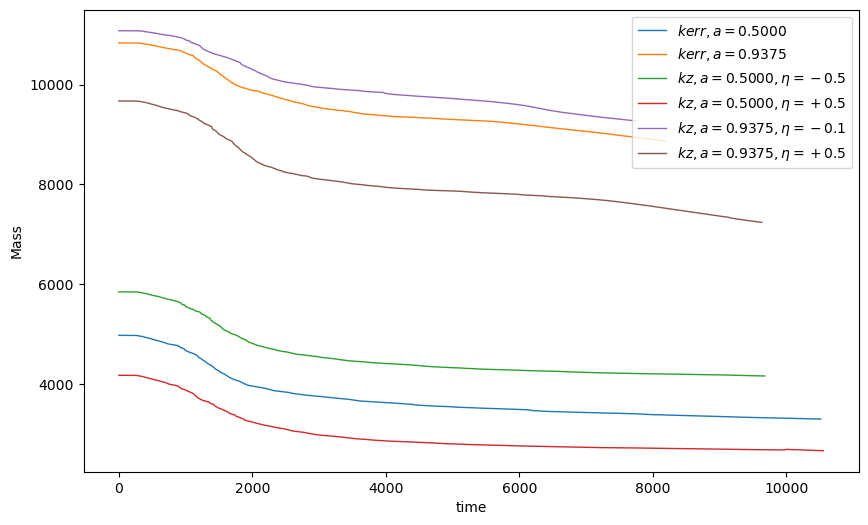

In [10]:
fig3, ax3 = plt.subplots(1,1,figsize=(10, 6))

#plot mass
ax3.plot(t0, Mass0, label=label0, alpha=1.0, linewidth=1.0)
ax3.plot(t1, Mass1, label=label1, alpha=1.0, linewidth=1.0)
ax3.plot(t2, Mass2, label=label2, alpha=1.0, linewidth=1.0)
ax3.plot(t3, Mass3, label=label3, alpha=1.0, linewidth=1.0)
ax3.plot(t4, Mass4, label=label4, alpha=1.0, linewidth=1.0)
ax3.plot(t5, Mass5, label=label5, alpha=1.0, linewidth=1.0)
ax3.legend()
ax3.set_xlabel('time')
ax3.set_ylabel('Mass') 
# ax5.set_yscale('log')
plt.show()

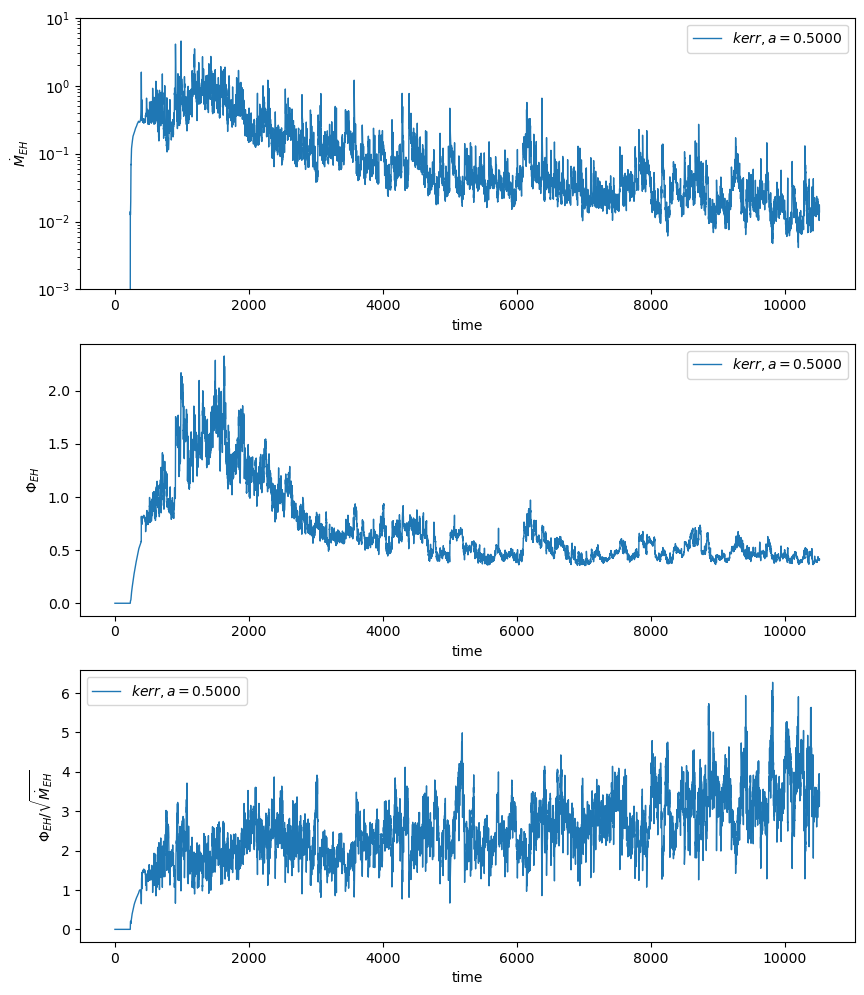

In [11]:
fig4, ax4 = plt.subplots(3,1,figsize=(10, 12))

ax4[0].plot(t0, Mdot_EH0, label=label0, alpha=1.0, linewidth=1.0) #min_A=0.2,
ax4[0].set_xlabel('time')
ax4[0].set_ylabel(r'$\dot{M}_{EH}$')
ax4[0].set_yscale('log')
ax4[0].set_ylim(1e-3,1e1)
# ax3[0].set_xlim(0,5000)
ax4[0].legend()

ax4[1].plot(t0, Phi_EH0, label=label0, alpha=1.0, linewidth=1.0) #min_A=0.2,
ax4[1].set_xlabel('time')
ax4[1].set_ylabel(r'$\Phi_{EH}$')
# ax3[1].set_xlim(0,5000)
ax4[1].legend()

ax4[2].plot(t0, Phi_EH0/np.sqrt(Mdot_EH0), label=label0, alpha=1.0, linewidth=1.0) #min_A=0.2,
ax4[2].set_xlabel('time')
ax4[2].set_ylabel(r'$\Phi_{EH}/\sqrt{\dot{M}_{EH}}$')
# ax3[2].set_xlim(0,5000)
ax4[2].legend()

# ax3[3].plot(t3, Phi_EH3/np.sqrt(np.average(Mdot_EH3[avt:])), label=r'$SANE 1024x512x1,a=0.9375,min_A=0.2,\gamma=4/3$', alpha=1.0, linewidth=1.0)
# ax3[3].set_xlabel('time')
# ax3[3].set_ylabel(r'$\Phi_{EH}/\sqrt{\langle \dot{M}_{EH} \rangle_{5000:end}}$')
# ax3[3].legend()

plt.show()


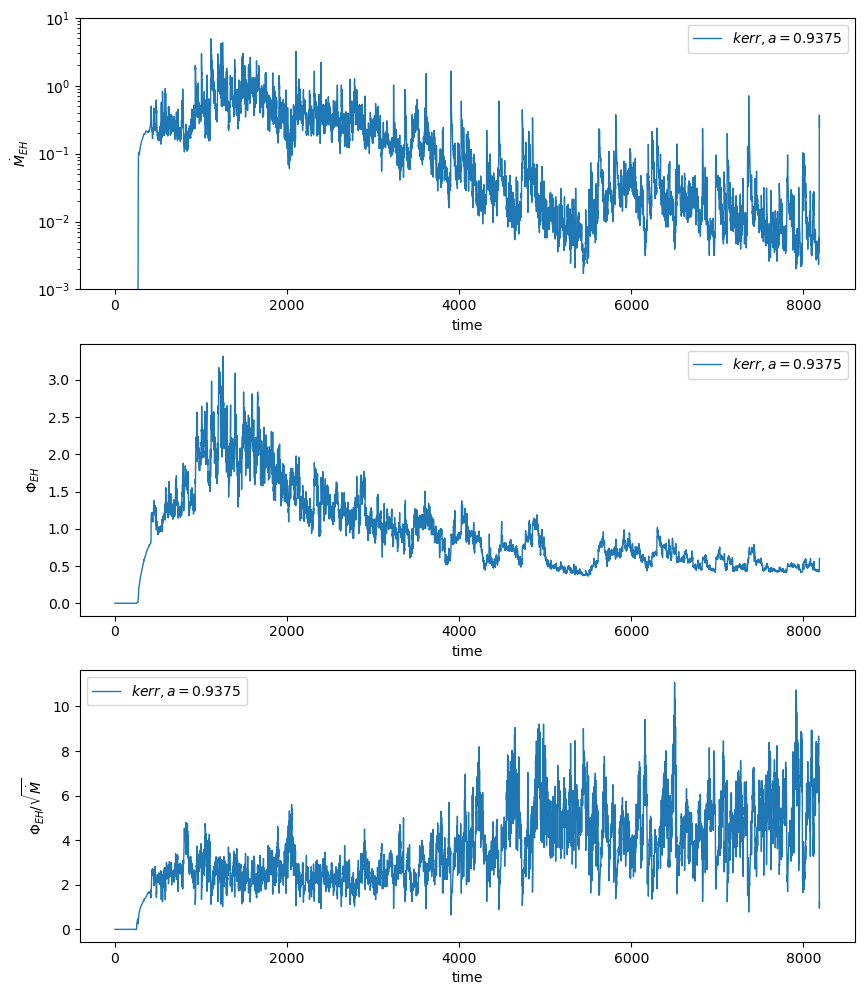

In [12]:
fig4, ax4 = plt.subplots(3,1,figsize=(10, 12))

ax4[0].plot(t1, Mdot_EH1, label=label1, alpha=1.0, linewidth=1.0) #min_A=0.2,
ax4[0].set_xlabel('time')
ax4[0].set_ylabel(r'$\dot{M}_{EH}$')
ax4[0].set_yscale('log')
ax4[0].set_ylim(1e-3,1e1)
ax4[0].legend()

ax4[1].plot(t1, Phi_EH1, label=label1, alpha=1.0, linewidth=1.0)
ax4[1].set_xlabel('time')
ax4[1].set_ylabel(r'$\Phi_{EH}$')
ax4[1].legend()

ax4[2].plot(t1, Phi_EH1/np.sqrt(Mdot_EH1), label=label1, alpha=1.0, linewidth=1.0)
ax4[2].set_xlabel('time')
ax4[2].set_ylabel(r'$\Phi_{EH}/\sqrt{\dot{M}}$')
ax4[2].legend()

# ax4[3].plot(t4, Phi_EH4/np.sqrt(np.average(Mdot_EH4[avt:])), label=r'$SANE,a=0.9375,min_A=0.2,\gamma=5/3$', alpha=1.0, linewidth=1.0)
# ax4[3].set_xlabel('time')
# ax4[3].set_ylabel(r'$\Phi_{EH}/\sqrt{\langle \dot{M}_{EH} \rangle_{5000:end}}$')
# ax4[3].legend()

plt.show()


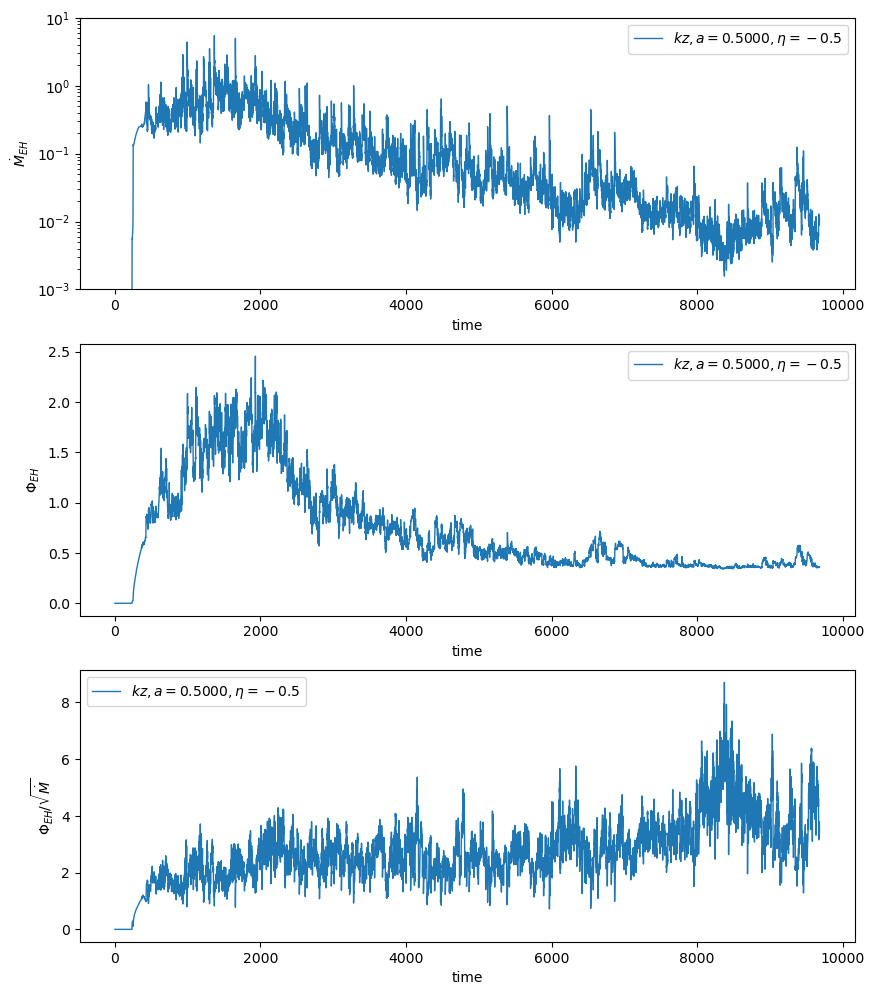

In [13]:
fig6, ax6 = plt.subplots(3,1,figsize=(10, 12))

ax6[0].plot(t2, Mdot_EH2, label=label2, alpha=1.0, linewidth=1.0) #min_A=0.2,
ax6[0].set_xlabel('time')
ax6[0].set_ylabel(r'$\dot{M}_{EH}$')
ax6[0].set_yscale('log')
ax6[0].set_ylim(1e-3,1e1)
ax6[0].legend()

ax6[1].plot(t2, Phi_EH2, label=label2, alpha=1.0, linewidth=1.0)
ax6[1].set_xlabel('time')
ax6[1].set_ylabel(r'$\Phi_{EH}$')
ax6[1].legend()

ax6[2].plot(t2, Phi_EH2/np.sqrt(Mdot_EH2), label=label2, alpha=1.0, linewidth=1.0)
ax6[2].set_xlabel('time')
ax6[2].set_ylabel(r'$\Phi_{EH}/\sqrt{\dot{M}}$')
ax6[2].legend()

# ax4[3].plot(t4, Phi_EH4/np.sqrt(np.average(Mdot_EH4[avt:])), label=r'$SANE,a=0.9375,min_A=0.2,\gamma=5/3$', alpha=1.0, linewidth=1.0)
# ax4[3].set_xlabel('time')
# ax4[3].set_ylabel(r'$\Phi_{EH}/\sqrt{\langle \dot{M}_{EH} \rangle_{5000:end}}$')
# ax4[3].legend()

plt.show()

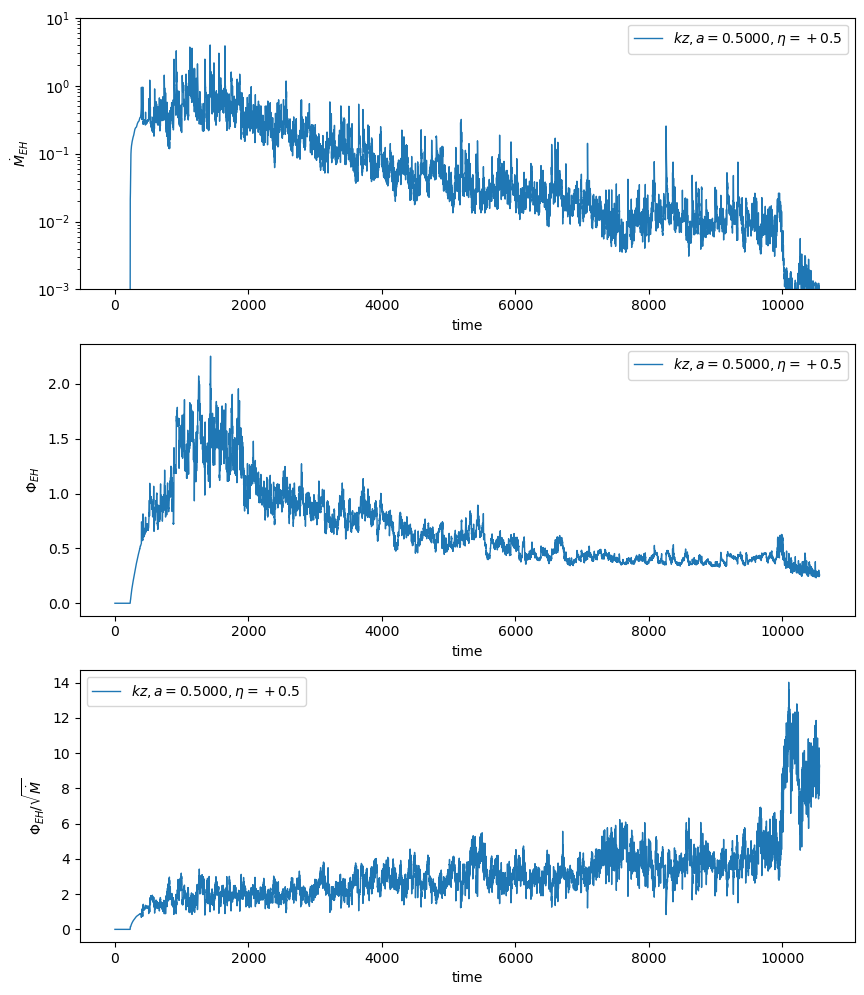

In [14]:
fig7, ax7 = plt.subplots(3,1,figsize=(10, 12))

ax7[0].plot(t3, Mdot_EH3, label=label3, alpha=1.0, linewidth=1.0) #min_A=0.2,
ax7[0].set_xlabel('time')
ax7[0].set_ylabel(r'$\dot{M}_{EH}$')
ax7[0].set_yscale('log')
ax7[0].set_ylim(1e-3,1e1)
ax7[0].legend()

ax7[1].plot(t3, Phi_EH3, label=label3, alpha=1.0, linewidth=1.0)
ax7[1].set_xlabel('time')
ax7[1].set_ylabel(r'$\Phi_{EH}$')
ax7[1].legend()

ax7[2].plot(t3, Phi_EH3/np.sqrt(Mdot_EH3), label=label3, alpha=1.0, linewidth=1.0)
ax7[2].set_xlabel('time')
ax7[2].set_ylabel(r'$\Phi_{EH}/\sqrt{\dot{M}}$')
ax7[2].legend()

# ax4[3].plot(t4, Phi_EH4/np.sqrt(np.average(Mdot_EH4[avt:])), label=r'$SANE,a=0.9375,min_A=0.2,\gamma=5/3$', alpha=1.0, linewidth=1.0)
# ax4[3].set_xlabel('time')
# ax4[3].set_ylabel(r'$\Phi_{EH}/\sqrt{\langle \dot{M}_{EH} \rangle_{5000:end}}$')
# ax4[3].legend()

plt.show()

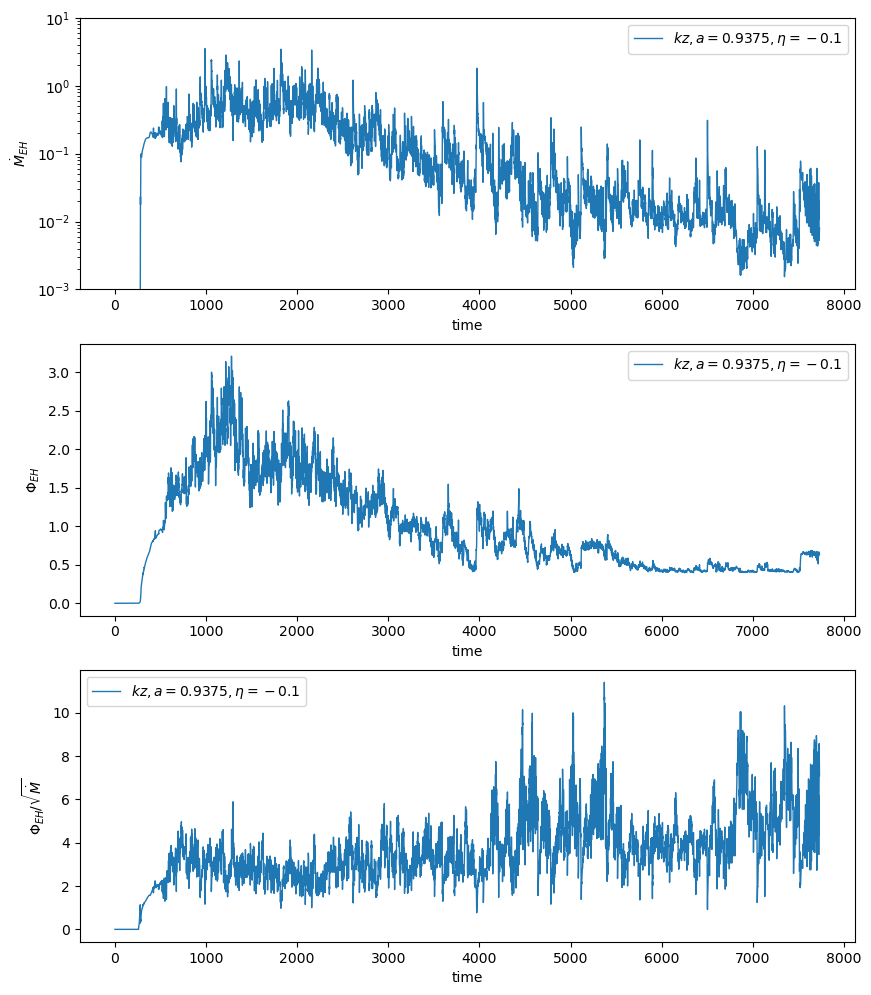

In [15]:
fig8, ax8 = plt.subplots(3,1,figsize=(10, 12))

ax8[0].plot(t4, Mdot_EH4, label=label4, alpha=1.0, linewidth=1.0) #min_A=0.2,
ax8[0].set_xlabel('time')
ax8[0].set_ylabel(r'$\dot{M}_{EH}$')
ax8[0].set_yscale('log')
ax8[0].set_ylim(1e-3,1e1)
ax8[0].legend()

ax8[1].plot(t4, Phi_EH4, label=label4, alpha=1.0, linewidth=1.0)
ax8[1].set_xlabel('time')
ax8[1].set_ylabel(r'$\Phi_{EH}$')
ax8[1].legend()

ax8[2].plot(t4, Phi_EH4/np.sqrt(Mdot_EH4), label=label4, alpha=1.0, linewidth=1.0)
ax8[2].set_xlabel('time')
ax8[2].set_ylabel(r'$\Phi_{EH}/\sqrt{\dot{M}}$')
ax8[2].legend()

# ax4[3].plot(t4, Phi_EH4/np.sqrt(np.average(Mdot_EH4[avt:])), label=r'$SANE,a=0.9375,min_A=0.2,\gamma=5/3$', alpha=1.0, linewidth=1.0)
# ax4[3].set_xlabel('time')
# ax4[3].set_ylabel(r'$\Phi_{EH}/\sqrt{\langle \dot{M}_{EH} \rangle_{5000:end}}$')
# ax4[3].legend()

plt.show()

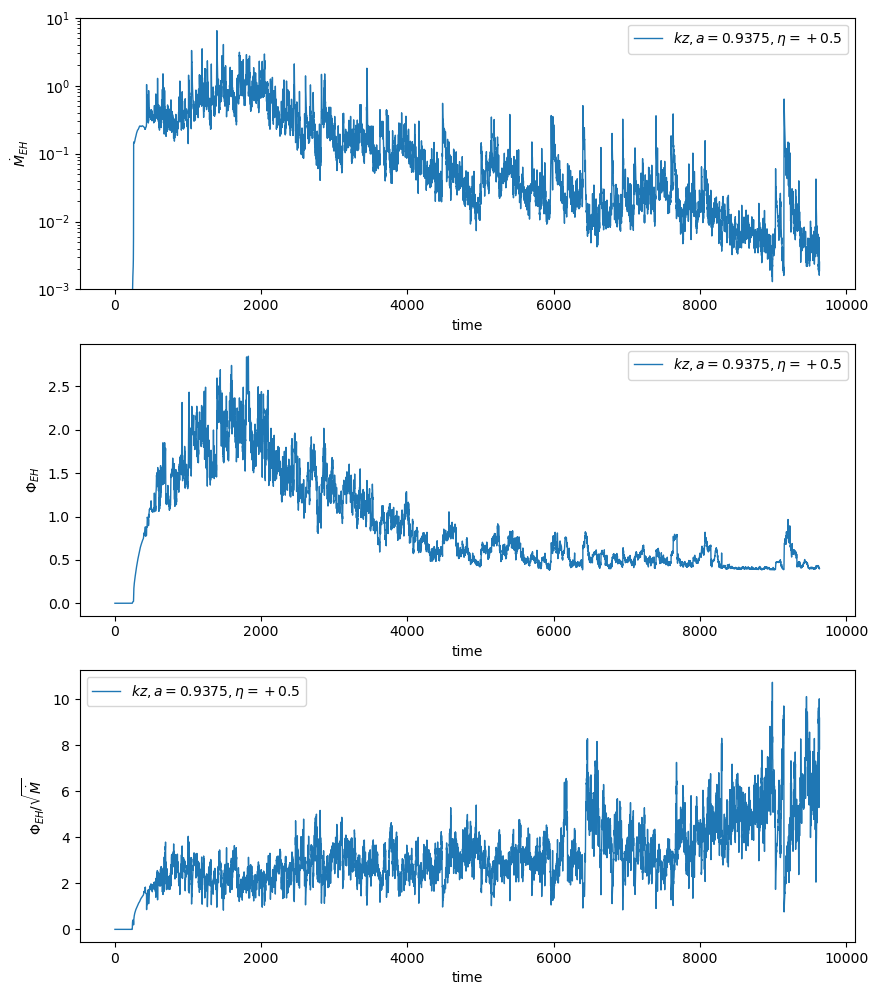

In [16]:
fig9, ax9 = plt.subplots(3,1,figsize=(10, 12))

ax9[0].plot(t5, Mdot_EH5, label=label5, alpha=1.0, linewidth=1.0) #min_A=0.2,
ax9[0].set_xlabel('time')
ax9[0].set_ylabel(r'$\dot{M}_{EH}$')
ax9[0].set_yscale('log')
ax9[0].set_ylim(1e-3,1e1)
ax9[0].legend()

ax9[1].plot(t5, Phi_EH5, label=label5, alpha=1.0, linewidth=1.0)
ax9[1].set_xlabel('time')
ax9[1].set_ylabel(r'$\Phi_{EH}$')
ax9[1].legend()

ax9[2].plot(t5, Phi_EH5/np.sqrt(Mdot_EH5), label=label5, alpha=1.0, linewidth=1.0)
ax9[2].set_xlabel('time')
ax9[2].set_ylabel(r'$\Phi_{EH}/\sqrt{\dot{M}}$')
ax9[2].legend()

# ax4[3].plot(t4, Phi_EH4/np.sqrt(np.average(Mdot_EH4[avt:])), label=r'$SANE,a=0.9375,min_A=0.2,\gamma=5/3$', alpha=1.0, linewidth=1.0)
# ax4[3].set_xlabel('time')
# ax4[3].set_ylabel(r'$\Phi_{EH}/\sqrt{\langle \dot{M}_{EH} \rangle_{5000:end}}$')
# ax4[3].legend()

plt.show()